In [1]:
from pathlib import Path
import ast

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

csv_path = Path("novel_discovery_per_entity.csv")
df = pd.read_csv(csv_path)
df["top_predicted_labels"] = df["top_predicted_labels"].apply(ast.literal_eval)
df["class_round"] = df.apply(lambda row: f"R{row['round']} - {row['true_label']}", axis=1)

df

,true_label,num_nodes,num_communities,dominant_comm_id,dominant_comm_size,concentration,named_predictions,cluster_x_predictions,top_predicted_labels,round,class_round
0,Jetmint,2,2,8,1,0.500000,1,1,"{'CLUSTER_8': 1, 'SCAM': 1}",1,R1 - Jetmint
1,Dead Project,2,2,9,1,0.500000,1,1,"{'SCAM': 1, 'CLUSTER_21': 1}",1,R1 - Dead Project
2,Wirex,19,4,5,13,0.684211,1,18,"{'CLUSTER_5': 13, 'CLUSTER_4': 4, 'SCAM': 1, '...",1,R1 - Wirex
3,Spam Issuer,4,1,9,4,1.000000,4,0,{'SCAM': 4},1,R1 - Spam Issuer
4,Altilly,2,1,11,2,1.000000,0,2,{'CLUSTER_11': 2},1,R1 - Altilly
5,Stably,2,2,5,1,0.500000,0,2,"{'CLUSTER_5': 1, 'CLUSTER_4': 1}",1,R1 - Stably
6,UltraCapital,8,3,12,4,0.500000,5,3,"{'AQUA': 4, 'CLUSTER_3': 3, 'SCAM': 1}",1,R1 - UltraCapital
7,FreightCoin,2,2,4,1,0.500000,0,2,"{'CLUSTER_4': 1, 'CLUSTER_15': 1}",1,R1 - FreightCoin
8,AnchorUSD,2,2,80,1,0.500000,1,1,"{'Centre': 1, 'CLUSTER_31': 1}",1,R1 - AnchorUSD
9,Cryptomover,4,3,9,2,0.500000,3,1,"{'SCAM': 2, 'CLUSTER_21': 1, 'AQUA': 1}",1,R1 - Cryptomover


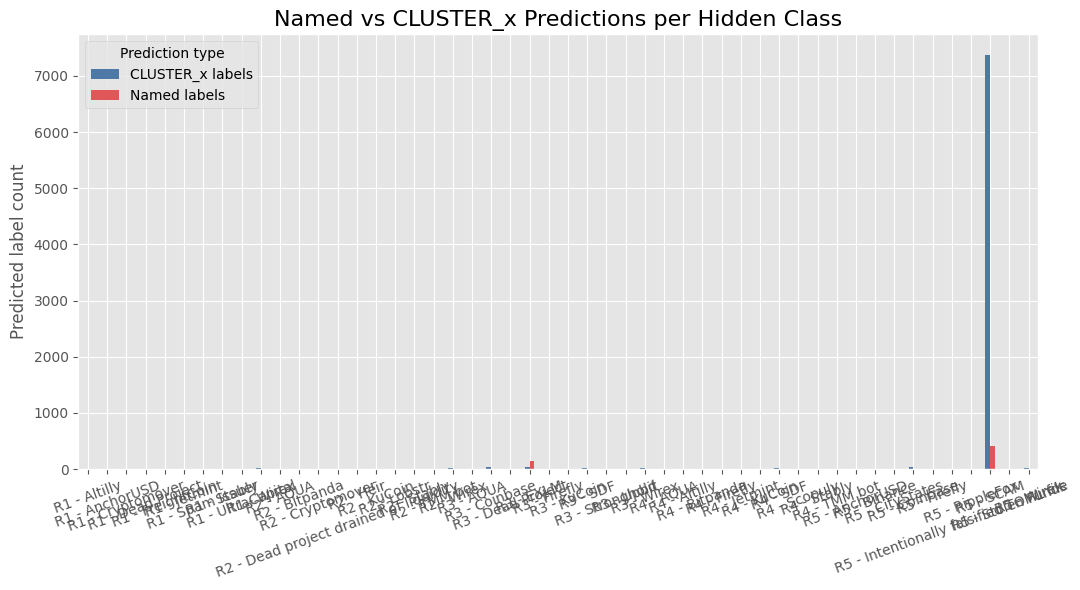

In [2]:
plot_df = df[["class_round", "named_predictions", "cluster_x_predictions"]].copy()
plot_df = plot_df.melt(
    id_vars="class_round",
    value_vars=["named_predictions", "cluster_x_predictions"],
    var_name="prediction_type",
    value_name="count",
)
plot_df["prediction_type"] = plot_df["prediction_type"].map({
    "named_predictions": "Named labels",
    "cluster_x_predictions": "CLUSTER_x labels",
})

pivot_df = plot_df.pivot(index="class_round", columns="prediction_type", values="count")

fig, ax = plt.subplots(figsize=(11, 6))
pivot_df.plot(
    kind="bar",
    color=["#4e79a7", "#e15759"],
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("Predicted label count")
ax.set_title("Named vs CLUSTER_x Predictions per Hidden Class")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Prediction type")
plt.tight_layout()
plt.show()

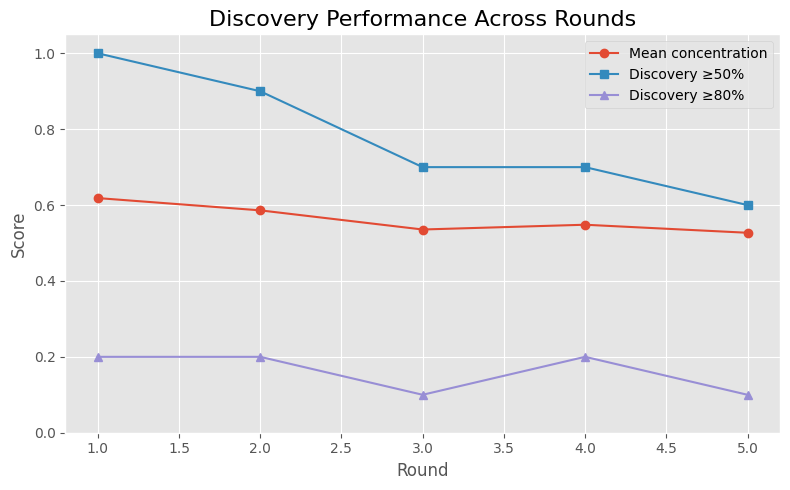

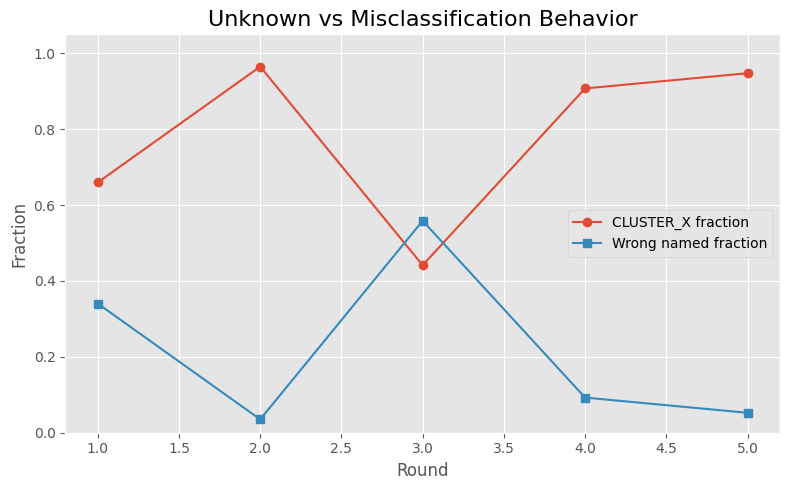

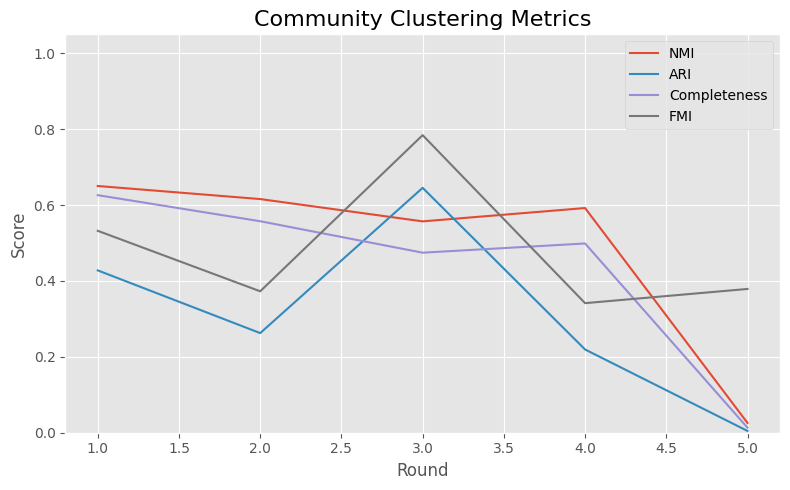

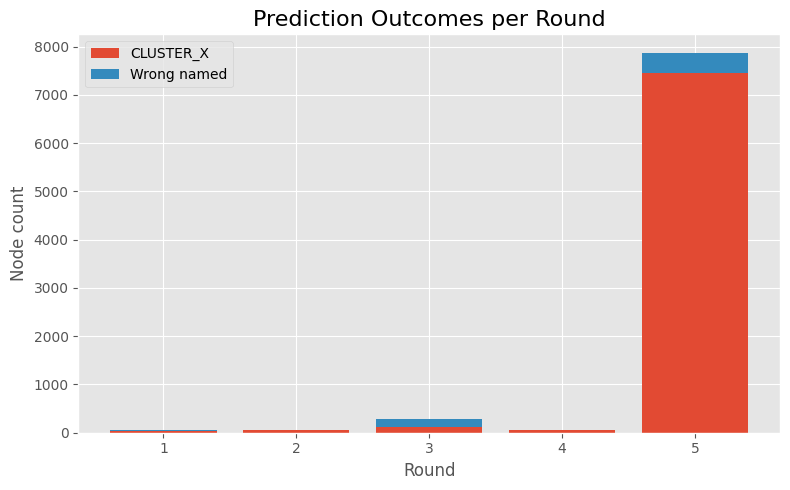

In [3]:

df = pd.read_csv("novel_discovery_per_round.csv")

# -----------------------------
# 1. Discovery quality plot
# -----------------------------
plt.figure(figsize=(8, 5))

plt.plot(df["round"], df["mean_concentration"], marker="o", label="Mean concentration")
plt.plot(df["round"], df["discovery_rate_50pct"], marker="s", label="Discovery ≥50%")
plt.plot(df["round"], df["discovery_rate_80pct"], marker="^", label="Discovery ≥80%")

plt.xlabel("Round")
plt.ylabel("Score")
plt.title("Discovery Performance Across Rounds")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# 2. CLUSTER_X vs Wrong labels
# -----------------------------
plt.figure(figsize=(8, 5))

plt.plot(df["round"], df["cluster_x_frac"], marker="o", label="CLUSTER_X fraction")
plt.plot(df["round"], df["named_wrong_frac"], marker="s", label="Wrong named fraction")

plt.xlabel("Round")
plt.ylabel("Fraction")
plt.title("Unknown vs Misclassification Behavior")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Clustering metrics
plt.figure(figsize=(8, 5))

plt.plot(df["round"], df["NMI_community"], label="NMI")
plt.plot(df["round"], df["ARI_community"], label="ARI")
plt.plot(df["round"], df["Completeness_community"], label="Completeness")
plt.plot(df["round"], df["FMI_community"], label="FMI")

plt.xlabel("Round")
plt.ylabel("Score")
plt.title("Community Clustering Metrics")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. Stacked bar (counts)
plt.figure(figsize=(8, 5))

x = df["round"]

plt.bar(x, df["cluster_x_count"], label="CLUSTER_X")
plt.bar(x, df["named_wrong_count"], bottom=df["cluster_x_count"], label="Wrong named")

plt.xlabel("Round")
plt.ylabel("Node count")
plt.title("Prediction Outcomes per Round")
plt.legend()
plt.tight_layout()
plt.show()

summary 

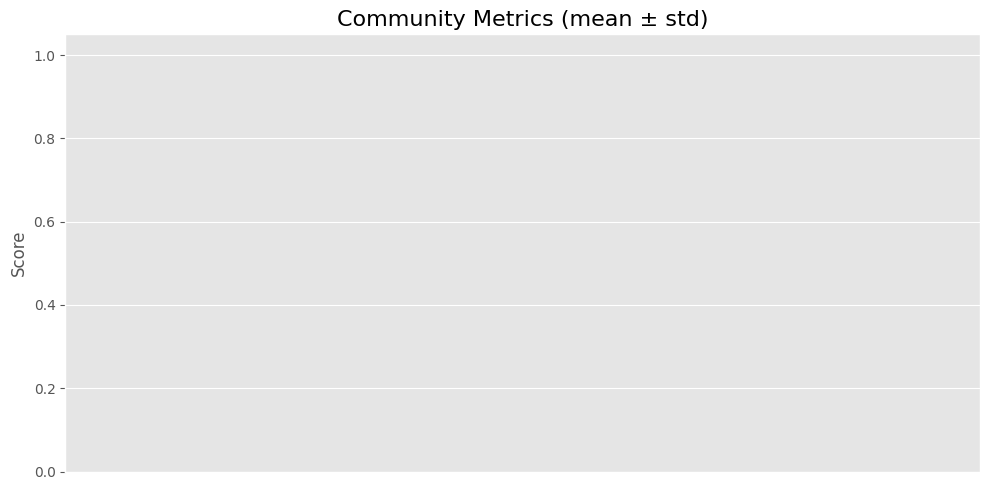

In [4]:

df = pd.read_csv("novel_discovery_summary.csv")

# Split into community and mapped
df_comm = df[df["scope"] == "community"]
df_map = df[df["scope"] == "mapped"]

# -----------------------------
# Bar plot with error bars
# -----------------------------
plt.figure(figsize=(10, 5))

x = range(len(df_comm))

plt.bar(
    x,
    df_comm["mean"],
    yerr=df_comm["std"],
    capsize=5
)

plt.xticks(x, df_comm["metric"], rotation=30)
plt.ylabel("Score")
plt.title("Community Metrics (mean ± std)")
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()